In [1]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


1.Scalars, vectors, matrices & tensors

In [2]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [3]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [27]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
import numpy as np

T = np.arange(12).reshape(3, 4)

# Get the number of dimensions
print("Number of dimensions (ndim):", T.ndim)

# Get the shape
print("Shape of the array (shape):", T.shape)


# 2. T + T
import numpy as np

# Create the original array
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# Add T to itself
print('\nT + T:\n', T + T)


# 3. Transpose (print .T.shape) and reshape to (2, 6)
import numpy as np

# Initial array setup
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 3. Transpose, print .T.shape, and reshape to (2, 6)
T_transposed = T.T
print('.T.shape:\n', T_transposed.shape)

T_reshaped = T_transposed.reshape(2, 6)
print('Reshaped to (2, 6):\n', T_reshaped)


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Number of dimensions (ndim): 2
Shape of the array (shape): (3, 4)
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
.T.shape:
 (4, 3)
Reshaped to (2, 6):
 [[ 0  4  8  1  5  9]
 [ 2  6 10  3  7 11]]


2. Dot & cross products, and norms


In [5]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [6]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [28]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    # 2. cosine similarity of u and v
   import numpy as np
from numpy.linalg import norm

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])), # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])), # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])), # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    l1_u = norm(u, 1)
    l2_u = norm(u, 2)

    # 2. cosine similarity of u and v
    cos_sim = np.dot(u, v) / (norm(u) * norm(v))

    print(f"--- Pair {i} ---")
    print(f"u = {u}, v = {v}")
    print(f"L1 norm of u: {l1_u}")
    print(f"L2 norm of u: {l2_u:.3f}")
    print(f"Cosine similarity: {cos_sim:.3f}\n")

# 3. Most similar pair = Pair 1

    pass


--- Pair 1 ---
u = [1 0 1], v = [1 0 1]
L1 norm of u: 2.0
L2 norm of u: 1.414
Cosine similarity: 1.000

--- Pair 2 ---
u = [1 2 3], v = [3 2 1]
L1 norm of u: 6.0
L2 norm of u: 3.742
Cosine similarity: 0.714

--- Pair 3 ---
u = [2 0 0], v = [0 5 0]
L1 norm of u: 2.0
L2 norm of u: 2.000
Cosine similarity: 0.000



3. Matrix operations & special matrices

In [12]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [13]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [29]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])

# Find the inverse
M_inv = np.linalg.inv(M)
print("Inverse of M:\n", M_inv)

# Find the trace
M_trace = np.trace(M)
print("Trace of M:", M_trace)


# 2. M @ inv(M) == I ?
import numpy as np

M = np.array([[4., 2.], [2., 3.]])

# Compute the inverse
inv_M = np.linalg.inv(M)

# Correct way to check equality for floats
is_identity = np.allclose(M @ inv_M, np.eye(2))
print(is_identity)  # Returns: True


# 3. Is M symmetric? Is P orthogonal?
import numpy as np

M = np.array([[4., 2.], [2., 3.]])
# Fixed the typo in P by adding the missing closing quote to "-1."
P = np.array([[0., -1.], [1., 0.]])

# 1. Check if M is symmetric
is_M_symmetric = np.allclose(M, M.T)
print(f"Is M symmetric? {is_M_symmetric}")

# 2. Check if P is orthogonal (P^T @ P must equal the identity matrix)
I = np.eye(2)
is_P_orthogonal = np.allclose(P.T @ P, I)
print(f"Is P orthogonal? {is_P_orthogonal}")


Inverse of M:
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M: 7.0
True
Is M symmetric? True
Is P orthogonal? True


4. Transformations: rotation & scaling

In [16]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)



Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


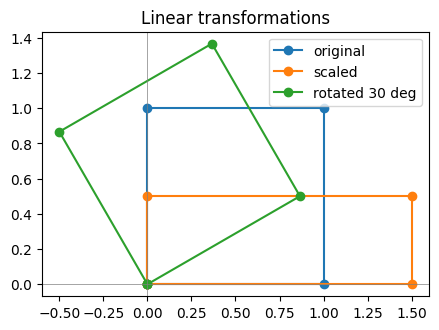

In [17]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

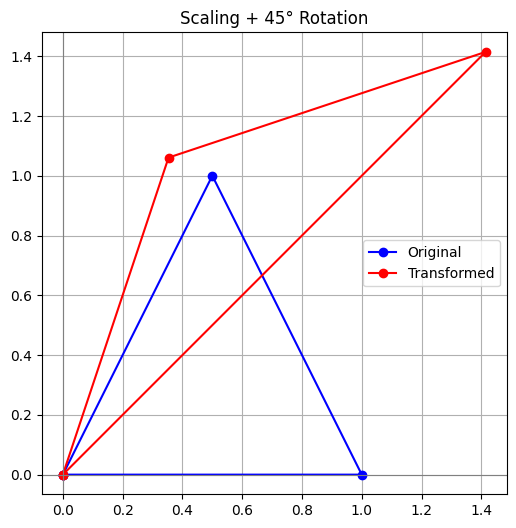

In [32]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
# YOUR CODE HERE

# 2. Rotation matrix (45 degrees)
# YOUR CODE HERE

# 3. Apply both and plot original vs transformed
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# Helper function to close the triangle
def close_loop(X):
    return np.hstack([X, X[:, :1]])

# 1. Scaling matrix: x * 2, y * 0.5
S = np.array([[2, 0],
              [0, 0.5]])

# 2. Rotation matrix: 45 degrees
theta = np.deg2rad(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# 3. Apply both transformations
# First scale, then rotate
tri_transformed = R @ (S @ tri)

# Close loops for plotting
tri_closed = close_loop(tri)
transformed_closed = close_loop(tri_transformed)

# Plot original vs transformed
plt.figure(figsize=(6, 6))

plt.plot(tri_closed[0], tri_closed[1],
         'bo-', label='Original')

plt.plot(transformed_closed[0], transformed_closed[1],
         'ro-', label='Transformed')

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.title('Scaling + 45° Rotation')

plt.show()



5. Eigenvalues & eigenvectors

In [19]:
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [20]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [36]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
# YOUR CODE HERE

# 2. print eigenvalues
# YOUR CODE HERE

# 3. verify A v = lambda v for the first eigenvector
# YOUR CODE HERE
import numpy as np
import numpy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

# 1. Eigenvalues and eigenvectors
eigenvalues, eigenvectors = la.eig(C)

# 2. Print eigenvalues
print("Eigenvalues:")
print(eigenvalues)

print("Eigenvectors:")
print(eigenvectors)

# 3. Verify C @ v = lambda * v for the first eigenvector
v = eigenvectors[:, 0]
lam = eigenvalues[0]

print("Verification:",np.allclose(C @ v, lam * v))





Eigenvalues:
[5. 2.]
Eigenvectors:
[[ 0.707 -0.447]
 [ 0.707  0.894]]
Verification: True


6. Rank, solving systems & cosine similarity

In [22]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [23]:
# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [33]:
# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [37]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
import numpy as np

A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

x = np.linalg.solve(A2, b2)
print("Solution for x:", x)
# Result: [ 0.2  3.2]

# 2. Rank of A2
rank_A2 = np.linalg.matrix_rank(A2)
print("Rank of A2:", rank_A2)
# Result: 2


# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

sim_cat_dog = cosine_similarity(cat, dog)
sim_cat_car = cosine_similarity(cat, car)

print("Cosine(cat, dog):", sim_cat_dog)
print("Cosine(cat, car):", sim_cat_car)


Solution for x: [1. 2.]
Rank of A2: 2
Cosine(cat, dog): 0.9946195449838785
Cosine(cat, car): 0.29255678516966266
